In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
from dotenv import load_dotenv

## Results DMRIR Downstream 

In [ ]:
load_dotenv()
ROOT_DIR = Path(os.getenv("ROOT_DIR"))
results_path = ROOT_DIR / "results" /"classification_fulltestset_resultsV2.csv"
df = pd.read_csv(results_path)
df

,n_samples,cv_fold,f1,precision,recall,auc
0,64,0,0.844106,0.982301,0.740000,0.863333
1,64,1,0.841727,0.914062,0.780000,0.853333
2,64,2,0.825279,0.932773,0.740000,0.843333
3,64,3,0.653153,0.493197,0.966667,0.486667
4,64,4,0.817844,0.924370,0.733333,0.836667
5,128,0,0.924731,1.000000,0.860000,0.930000
6,128,1,0.916084,0.963235,0.873333,0.920000
7,128,2,0.939929,1.000000,0.886667,0.943333
8,128,3,0.934256,0.971223,0.900000,0.936667
9,128,4,0.911032,0.977099,0.853333,0.916667


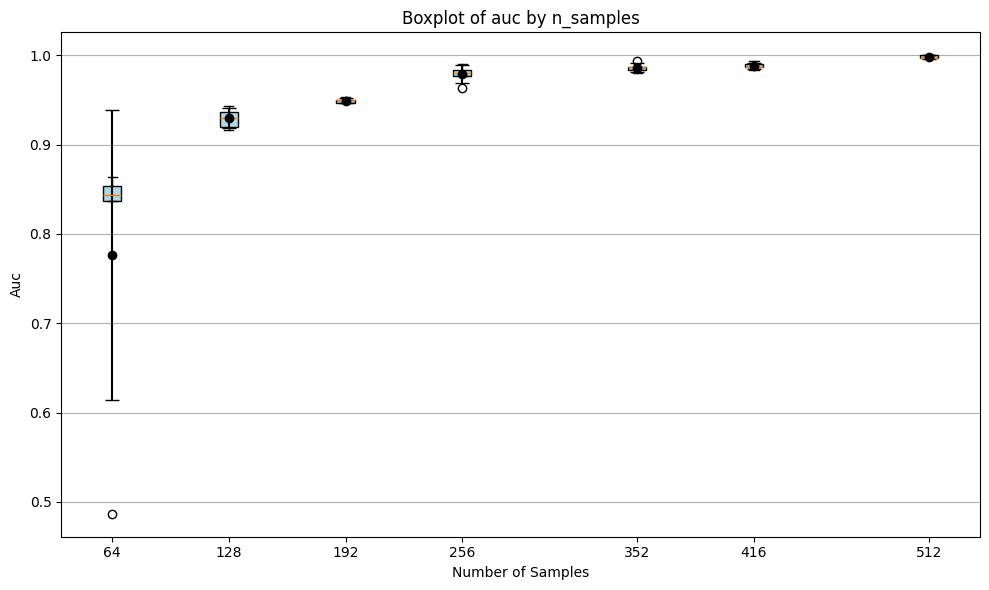

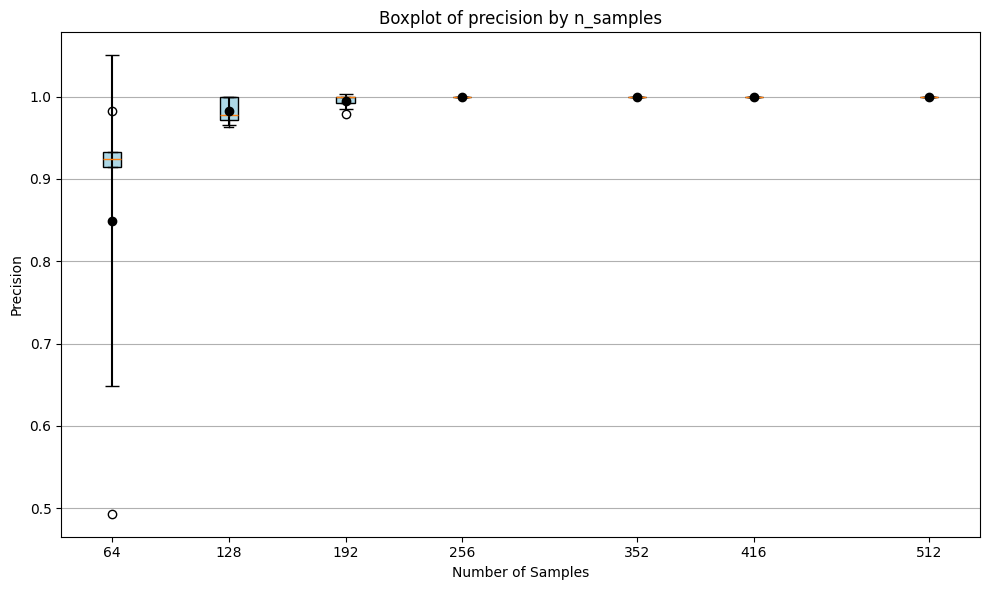

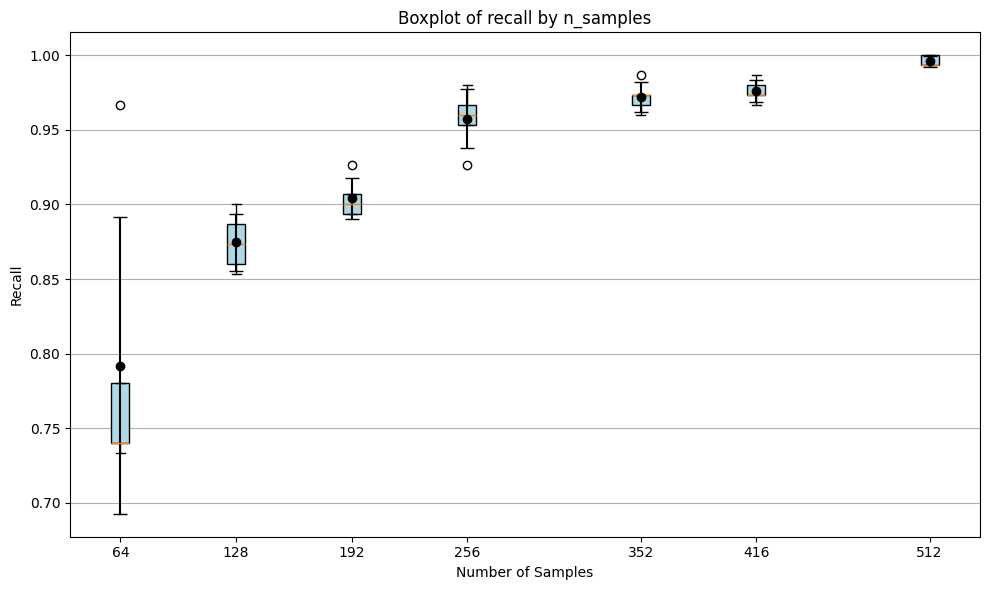

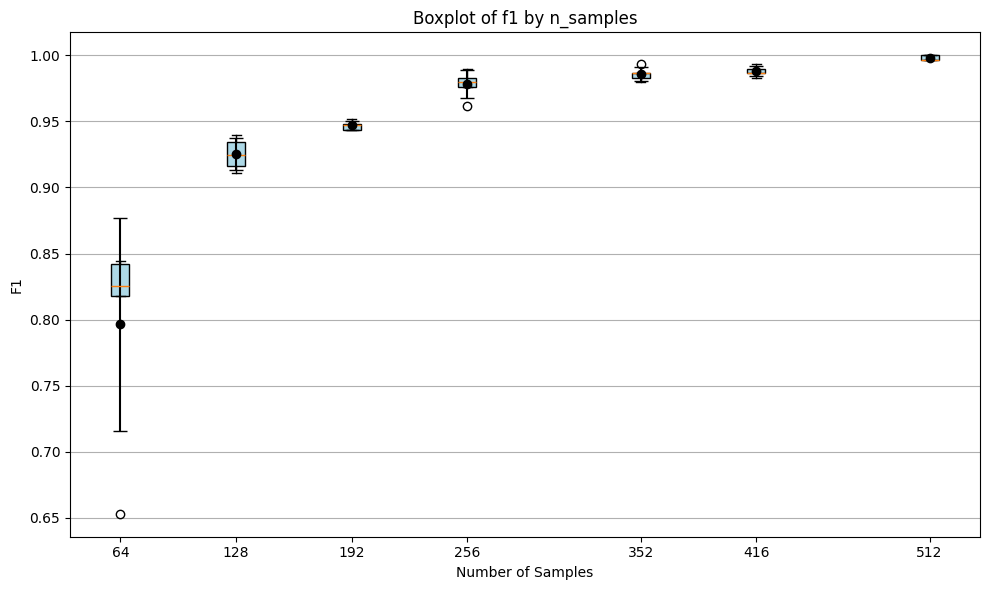

In [ ]:
unique_n_samples = df['n_samples'].unique()
metrics = ['auc', 'precision', 'recall', 'f1']

for metric in metrics:
    plt.figure(figsize=(10, 6))
    for n_samples in unique_n_samples:
        subset = df[df['n_samples'] == n_samples]
        plt.boxplot(subset[metric], positions=[n_samples], widths=10, patch_artist=True, boxprops=dict(facecolor='lightblue'))
        plt.errorbar(n_samples, subset[metric].mean(), yerr=subset[metric].std(), fmt='o', color='black', capsize=5)

    plt.title(f'Boxplot of {metric} by n_samples')
    plt.xlabel('Number of Samples')
    plt.ylabel(metric.capitalize())
    plt.xticks(unique_n_samples)
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()